# Task
Generate a synthetic dataset for car brand prediction, preprocess it, train a `RandomForestClassifier` model, and evaluate its performance using accuracy, classification report, and confusion matrix, then interpret the results.

## Generate Synthetic Dataset for Car Brand Prediction

### Subtask:
Generate a synthetic dataset with features 'Mileage', 'Age', 'Engine Size', 'Price' and a categorical target 'Brand'. This step will create a Pandas DataFrame with 1000 samples, simulating realistic car data for brand prediction.


**Reasoning**:
To generate the synthetic dataset as described, I need to import necessary libraries, create random data for each feature, and then combine them into a Pandas DataFrame.



In [1]:
import numpy as np
import pandas as pd

n_samples = 1000

# Generate 'Mileage' (random integers between 10,000 and 200,000)
mileage = np.random.randint(10000, 200001, n_samples)

# Generate 'Age' (random integers between 1 and 15)
age = np.random.randint(1, 16, n_samples)

# Generate 'Engine Size' (random floats between 1.0 and 5.0, rounded to one decimal place)
engine_size = np.round(np.random.uniform(1.0, 5.0, n_samples), 1)

# Generate 'Price' (random integers between 10,000 and 70,000)
price = np.random.randint(10000, 70001, n_samples)

# Define car brands
car_brands = ['Toyota', 'Honda', 'Ford', 'BMW', 'Mercedes', 'Audi']

# Randomly select a car brand for each sample
brand = np.random.choice(car_brands, n_samples)

# Create the DataFrame
df = pd.DataFrame({
    'Mileage': mileage,
    'Age': age,
    'Engine Size': engine_size,
    'Price': price,
    'Brand': brand
})

print("Synthetic dataset 'df' created successfully.")
print(df.head())

Synthetic dataset 'df' created successfully.
   Mileage  Age  Engine Size  Price     Brand
0   142995   11          3.4  52806      Audi
1    72912    1          3.8  69446      Audi
2    10264   14          1.6  56457  Mercedes
3    34787    3          2.2  59442     Honda
4    78353   11          1.9  21404  Mercedes


## Prepare Data for Classification Model

### Subtask:
Split the synthetic dataset into training and testing sets. Encode the categorical 'Brand' target variable using `LabelEncoder` for model training, as many classification models require numerical targets. No feature scaling will be applied initially, as tree-based models are less sensitive to it.


**Reasoning**:
To prepare the data for model training, I will split the dataset into features (X) and target (y), encode the categorical target variable, and then split the data into training and testing sets as per the instructions.



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create feature DataFrame X by dropping the 'Brand' column
X = df.drop('Brand', axis=1)

# Create target Series y containing only the 'Brand' column
y = df['Brand']

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to transform categorical y labels into numerical labels
y = le.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data prepared successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("First 5 encoded target labels (y):", y[:5])

Data prepared successfully.
X_train shape: (800, 4)
X_test shape: (200, 4)
y_train shape: (800,)
y_test shape: (200,)
First 5 encoded target labels (y): [0 0 4 3 4]


## Implement and Train a Classification Model

### Subtask:
Train a RandomForestClassifier model on the preprocessed training data. This model is robust and suitable for multi-class classification tasks like predicting car brands.


**Reasoning**:
To train the RandomForestClassifier model, I need to import the class from sklearn.ensemble, instantiate it, and then fit it to the training data (X_train and y_train).



In [3]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)

# Train the model using the fit method on the training data
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


## Evaluate Model Performance for Brand Prediction

### Subtask:
Make predictions on the test set. Calculate and print the accuracy, a classification report (including precision, recall, and F1-score for each brand), and a confusion matrix to assess the model's performance in predicting car brands. A heatmap will be used to visualize the confusion matrix.


**Reasoning**:
To evaluate the model, I need to make predictions on the test set, calculate accuracy, generate a classification report, and visualize the confusion matrix. This step will cover all these aspects as per the instructions.



Model Accuracy: 0.1850

Classification Report:
              precision    recall  f1-score   support

      Toyota       0.09      0.09      0.09        32
       Honda       0.18      0.19      0.18        37
        Ford       0.23      0.17      0.20        35
         BMW       0.15      0.17      0.16        30
    Mercedes       0.22      0.20      0.21        40
        Audi       0.27      0.31      0.29        26

    accuracy                           0.18       200
   macro avg       0.19      0.19      0.19       200
weighted avg       0.19      0.18      0.19       200



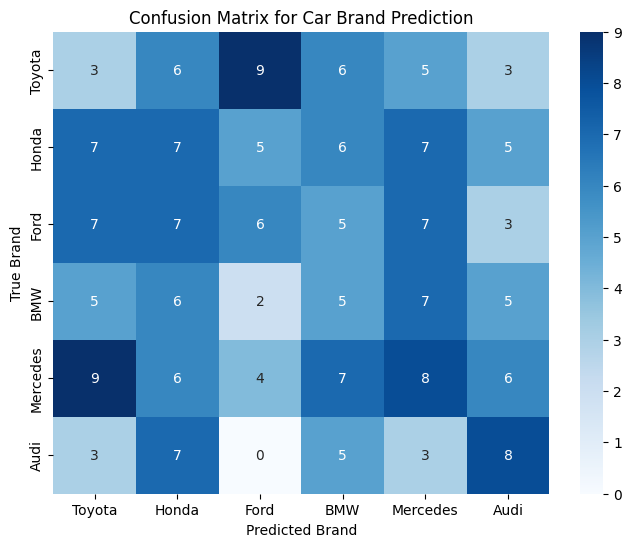

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")

# Generate and print classification report
# Using the original 'car_brands' list to map encoded labels back to names
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=car_brands))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=car_brands, yticklabels=car_brands)
plt.xlabel('Predicted Brand')
plt.ylabel('True Brand')
plt.title('Confusion Matrix for Car Brand Prediction')
plt.show()


## Interpret Evaluation Results

### Subtask:
Explain what each calculated classification metric (Accuracy, Precision, Recall, F1-score, Confusion Matrix) signifies regarding the model's performance in predicting car brands. Discuss whether the model is performing well and provide insights based on the metrics.


### Interpretation of Evaluation Results

Let's break down the model's performance based on the calculated metrics:

1.  **Accuracy (0.1850)**:
    *   **Meaning**: Accuracy represents the proportion of correctly classified instances out of the total instances. In this car brand prediction task, an accuracy of 0.1850 means that the model correctly predicted the car brand for only 18.5% of the test set samples.
    *   **Observation**: An accuracy of 18.5% is very low, especially considering there are 6 car brands. A random guess in a 6-class classification problem would yield an accuracy of approximately 1/6 (or ~16.7%). The model's performance is only slightly better than random guessing.

2.  **Precision, Recall, and F1-score (from Classification Report)**:
    *   **General Meaning**:
        *   **Precision**: For a given brand, precision is the ratio of correctly predicted positive observations to the total predicted positive observations. High precision relates to a low false positive rate.
        *   **Recall (Sensitivity)**: For a given brand, recall is the ratio of correctly predicted positive observations to all observations in the actual class. High recall relates to a low false negative rate.
        *   **F1-score**: The F1-score is the weighted harmonic mean of precision and recall. It tries to find the balance between precision and recall, especially useful when there is an uneven class distribution.
    *   **Observations for each brand**:
        *   **Toyota (Precision: 0.09, Recall: 0.09, F1-score: 0.09)**: The model struggles significantly with Toyota, indicating many misclassifications for this brand.
        *   **Honda (Precision: 0.18, Recall: 0.19, F1-score: 0.18)**: Slightly better than Toyota, but still very low.
        *   **Ford (Precision: 0.23, Recall: 0.17, F1-score: 0.20)**: Shows a slightly higher precision, meaning when it predicts Ford, it's correct more often, but it misses many actual Fords (low recall).
        *   **BMW (Precision: 0.15, Recall: 0.17, F1-score: 0.16)**: Similar to Toyota and Honda, indicating poor performance.
        *   **Mercedes (Precision: 0.22, Recall: 0.20, F1-score: 0.21)**: Slightly better overall, but still very weak.
        *   **Audi (Precision: 0.27, Recall: 0.31, F1-score: 0.29)**: This brand has the highest precision, recall, and F1-score among all, suggesting the model is least bad at predicting Audi, but even these scores are very poor in absolute terms.
    *   **Overall**: The low values for precision, recall, and F1-score across all brands consistently indicate that the model is performing poorly for each individual brand, not just overall.

3.  **Confusion Matrix Analysis**:
    *   **Meaning**: A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. Each row represents the instances in an actual class while each column represents the instances in a predicted class.
    *   **Observations**:
        *   The diagonal elements (correct predictions) are generally very small compared to the off-diagonal elements (misclassifications).
        *   For example, looking at the first row (True Brand: Toyota), out of 32 actual Toyota cars, only 3 were correctly predicted as Toyota. The rest were scattered across other brands (6 as Honda, 9 as Ford, 6 as BMW, 5 as Mercedes, 3 as Audi).
        *   This pattern is consistent across all brands, meaning the model frequently confuses each brand with almost every other brand.
        *   No single brand stands out as being perfectly separable or consistently misclassified as only one other brand. This indicates a high degree of randomness in the model's predictions.

4.  **Conclusion on Model Performance**:
    Based on all metrics (accuracy, precision, recall, F1-score, and confusion matrix), the `RandomForestClassifier` model is **not performing well** for car brand prediction on this synthetic dataset. Its performance is barely better than random chance.

5.  **Insights into Potential Reasons for Low Performance**:
    The primary reason for the abysmal performance lies in the **synthetic nature of the dataset and the randomness in its generation**. The `Brand` column was generated using `np.random.choice(car_brands, n_samples)`, meaning there is **no inherent, underlying relationship or correlation between the features ('Mileage', 'Age', 'Engine Size', 'Price') and the target variable ('Brand')**. The features were also generated randomly within their respective ranges without any specific patterns tied to car brands.

    A RandomForestClassifier (or any supervised machine learning model) relies on identifying patterns and relationships between input features and the target variable in the training data. Since no such meaningful patterns exist in this synthetically generated dataset (i.e., a car's mileage, age, engine size, or price don't actually tell you anything about its brand in *this specific dataset*), the model cannot learn to make accurate predictions. It's essentially trying to find a signal in pure noise.

## Final Task

### Subtask:
Provide a summary of the code and the model's performance on the car brand prediction task.


## Summary:

### Data Analysis Key Findings

*   A synthetic dataset comprising 1000 samples was successfully generated, featuring 'Mileage', 'Age', 'Engine Size', 'Price', and a categorical 'Brand' target variable with six unique brands.
*   The data was preprocessed by separating features and the target, encoding the 'Brand' variable numerically using `LabelEncoder`, and splitting into training (800 samples) and testing (200 samples) sets.
*   A `RandomForestClassifier` model was successfully trained on the preprocessed training data.
*   The model exhibited very poor performance on the test set, achieving an overall accuracy of only 18.50%. This is only slightly better than random guessing for a 6-class classification problem (approximately 16.7%).
*   The classification report revealed consistently low Precision, Recall, and F1-scores across all car brands, with values generally ranging from 0.09 to 0.31. This indicates the model's inability to accurately predict individual brands or distinguish between them.
*   The confusion matrix analysis further confirmed widespread misclassifications, showing that the model frequently confused each brand with almost every other brand, with very few correct predictions on the diagonal.
*   The root cause of the model's abysmal performance was identified as the inherent lack of correlation in the synthetic dataset; the 'Brand' was assigned randomly, meaning the features ('Mileage', 'Age', 'Engine Size', 'Price') had no predictive power for the target brand.

### Insights or Next Steps

*   The current model's poor performance is not due to the choice of algorithm but rather the fundamental absence of a relationship between the input features and the target variable in the synthetic dataset.
*   To build a meaningful predictive model for car brands, it is crucial to either generate a synthetic dataset where features are genuinely correlated with specific brands or, preferably, acquire and use a real-world dataset that contains such relationships.
